Locator attempting to generate 1001 ticks ([0.0, ..., 2.0]), which exceeds Locator.MAXTICKS (1000).


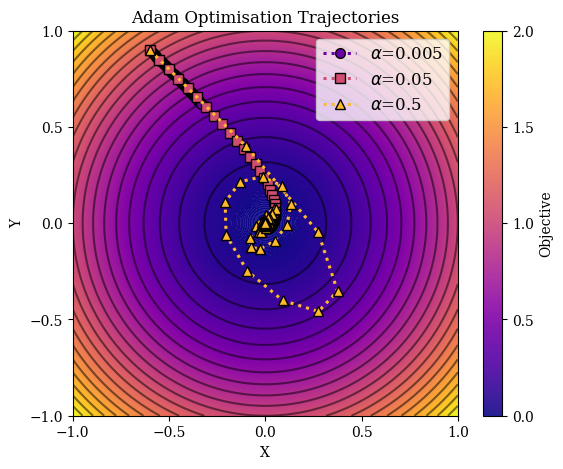

<Figure size 640x480 with 0 Axes>

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Serif'
# Objective function
def objective(x, y):
    return x ** 2.0 + y ** 2.0

# Derivative of the objective function
def derivative(x, y):
    return np.array([2.0 * x, 2.0 * y])

# Gradient descent algorithm with Adam
def adam(objective, derivative, bounds, x_0, n_iter,
         alpha, beta1, beta2, eps=1e-8):
    # Generate an initial point
    x = x_0.copy()
    scores = []
    trajectory = [x_0.copy()]

    # Initialize first and second moments
    m = np.zeros(bounds.shape[0])
    v = np.zeros(bounds.shape[0])

    # Run the gradient descent updates
    for t in range(n_iter):
        # Calculate gradient g(t)
        g = derivative(x[0], x[1])

        # Build a solution one variable at a time
        for i in range(x.shape[0]):
            # m(t) = beta1 * m(t-1) + (1 - beta1) * g(t)
            m[i] = beta1 * m[i] + (1.0 - beta1) * g[i]
            # v(t) = beta2 * v(t-1) + (1 - beta2) * g(t)^2
            v[i] = beta2 * v[i] + (1.0 - beta2) * g[i] ** 2
            # mhat(t) = m(t) / (1 - beta1(t))
            mhat = m[i] / (1.0 - beta1 ** (t + 1))
            # vhat(t) = v(t) / (1 - beta2(t))
            vhat = v[i] / (1.0 - beta2 ** (t + 1))
            # x(t) = x(t-1) - alpha * mhat(t) / (sqrt(vhat(t)) + eps)
            x[i] = x[i] - alpha * mhat / (np.sqrt(vhat) + eps)

        # Evaluate candidate point
        score = objective(x[0], x[1])
        scores.append(score)
        trajectory.append(x.copy())

    return x, scores, trajectory

# Define the range for input
bounds = np.array([[-1.0, 1.0], [-1.0, 1.0]])

# Define the total number of iterations
n_iter = 60

# Set the learning rates to compare
learning_rates = [0.005, 0.05, 0.5]

# Set the factor for average gradient
beta1 = 0.8

# Set the factor for average squared gradient
beta2 = 0.999

# Use the same starting point for each learning rate
initial_point = np.array([-0.6, 0.9])
runs = []
for learning_rate in learning_rates:
    best, scores, trajectory = adam(objective, derivative,
                                    bounds, initial_point, n_iter, learning_rate,
                                    beta1, beta2)
    runs.append((learning_rate, best, np.array(scores), np.array(trajectory)))

# Generate a grid of points for visualization
x = np.linspace(bounds[0, 0], bounds[0, 1], 100)
y = np.linspace(bounds[1, 0], bounds[1, 1], 100)
X, Y = np.meshgrid(x, y)
Z = objective(X, Y)

# Plot the optimization trajectories as a 2D contour map
fig, ax = plt.subplots(figsize=(6.5, 5))
contours = ax.contour(X, Y, Z, levels=20, colors='black', alpha=0.5)
contourf = ax.contourf(X, Y, Z, levels=1000, cmap='plasma', alpha=0.9)
fig.colorbar(contourf, ax=ax, label='Objective')
# Set the colour bar ticks to show the range of objective values
cbar = plt.gcf().axes[-1]
cbar.set_yticks(np.linspace(Z.min(), Z.max(), 5))
trajectory_colors = plt.cm.plasma(np.linspace(0.2, 0.85, len(runs)))
marker_styles = ['o', 's', '^']
for (learning_rate, best, scores, trajectory), line_color, marker_style in zip(runs, trajectory_colors, marker_styles):
    ax.plot(trajectory[:, 0], trajectory[:, 1], linestyle=':', linewidth=2.2,
            color=line_color, marker=marker_style,
            markerfacecolor=None, markeredgecolor='black', markersize=7,
            label=r'$\alpha$='+f'{learning_rate:g}')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_xticks([-1.0, -0.5, 0.0, 0.5, 1.0])
ax.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
ax.set_title('Adam Optimisation Trajectories')
ax.set_aspect('equal', adjustable='box')
ax.legend(fontsize=12)

# Show the plot
plt.show()
plt.savefig('adam_optimization_trajectories.pdf')